### TFBS Enrichment from sequence comparison: 
- Which TFBS are enriched in the sequences according to FIMO and lasso regression?
- RegioneReloaded NGN2 high activity, low activity sequences vs background
- RegioneReloaded NGN2 with and without epigenetic marks vs background
- Variant derived TFBS: Overlapping significant variants and the variant shows an effect on the binding affinity of the TFBS

In [ ]:
ngn2_with_and_without_epigenetic_makrs_old_path = "/home/kisa/coding/80K_MPRA/remap_chipseq_pia/80k_results/regioneReloaded_sampling1000_ngn2_with_and_without_epigenetic_marks_combined_tfbs_presence.csv"
ngn2_with_and_without_epigenetic_makrs_path = "/home/kisa/coding/80K_MPRA/remap_chipseq_pia/80k_results/regioneReloaded_sampling1000_ngn2_with_and_without_epigenetic_marks_enriched_depleted_combined_tfbs_presence.csv"

ngn2_undiffWTC11_high_activity_low_activity_old_path = "/home/kisa/coding/80K_MPRA/remap_chipseq_pia/80k_results/regioneReloaded_sampling1000_ngn2_and_undiffWTC11_remap2022_combined_tfbs_presence.csv"
ngn2_undiffWTC11_high_activity_low_activity_path = "/home/kisa/coding/80K_MPRA/remap_chipseq_pia/80k_results/regioneReloaded_sampling1000_ngn2_and_undiffWTC11_enriched_depleted_remap2022_combined_tfbs_presence.csv"

ngn2_high_low_activity_seq_old_path = "/home/kisa/coding/80K_MPRA/remap_chipseq_pia/80k_results/regioneReloaded_sampling1000_ngn2_high_low_remap2022_combined_tfbs_presence.csv"
ngn2_high_low_activity_seq_path = "/home/kisa/coding/80K_MPRA/remap_chipseq_pia/80k_results/regioneReloaded_sampling1000_ngn2_high_low_enriched_depleted_remap2022_combined_tfbs_presence.csv"

variant_based_decreasing_tfbs_motifs_path = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/tfbs_analysis/NGN2_best_sig_variant_based_decreasing_tfbs_motifs.tsv.gz"

variant_based_increasing_tfbs_motifs_path = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/tfbs_analysis/NGN2_best_sig_variant_based_increasing_tfbs_motifs.tsv.gz"

non_zero_coefficients_lasso_reg_path = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/tfbs_analysis/lasso_regression_a_00028096_non_zero_coefficients.tsv.gz"
lasso_regression_input_table_path = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/tfbs_analysis/lasso_regression_sequence_motif_table.tsv.gz"

In [ ]:
### Epigenetic marks:
# > print(pivot_table_significant_counts)
# # A tibble: 5 × 4
#   Alist_Region_Set                   NumberOfSignificantT…¹ NumberOfEnrichedTFBS
#   <chr>                                               <int>                <int>
# 1 Neuron_with_epigenetic_marks_incr…                    404                  403
# 2 Neuron_closed_chromatin_decreasing                    153                    3
# 3 background_conservative                                28                    3
# 4 Neuron_closed_chromatin_increasing                      0                    0
# 5 Neuron_with_epigenetic_marks_decr…                      0                    0

In [ ]:
### NGN2 and undiffWTC11 high activity, low activity sequences vs background
# > print(pivot_table_significant_counts)
# # A tibble: 5 × 4
#   Alist_Region_Set                 NumberOfSignificantTFBS NumberOfEnrichedTFBS
#   <chr>                                              <int>                <int>
# 1 Neuron_upregulating_dCREs                            111                  109
# 2 undiffWTC11_upregulating_dCREs                        73                   73
# 3 Neuron_downregulating_dCREs                           63                    3
# 4 background_conservative                                0                    0
# 5 undiffWTC11_downregulating_dCREs                       0                    0

In [ ]:
### NGN2 high activity, low activity sequences vs background
# > print(pivot_table_significant_counts)
# # A tibble: 3 × 4
#   Alist_Region_Set            NumberOfSignificantTFBS NumberOfEnrichedTFBS
#   <chr>                                         <int>                <int>
# 1 Neuron_upregulating_dCREs                       137                  134
# 2 Neuron_downregulating_dCREs                      29                    2
# 3 background_conservative                           0                    0
# # ℹ 1 more variable: NumberOfDepletedTFBS <int>

In [ ]:
### NGN2 lasso regression non-zero coefficients
# motif_id        coefficient
# ANDR.H13CORE.1.S.C      -0.00017035660566429712
# ANDR.H13CORE.2.P.B      -0.00011570246829635263
# AP2A.H13CORE.0.PSM.A    -2.7217082460563575e-05
# ARNT.H13CORE.0.P.B      -0.00046351698763140035
# BARH2.H13CORE.0.SM.B    0.00020964036000892654

In [4]:
import pandas as pd

### Process the regioneReloaded output:
- General: very few depletion events according to the RegioneReloaded output
- Interpretation of this data: 
    - A motif enriched in the set of "high activity" means it might be responsible for the activity observed
    - A motif depleted in the set of "high activity" means it might be responsible for reducing the activity in other sequences compared to this set
    - Example: I would like to know how well the TFBS which are associated with high activity align between the datasets:
        - For RegioneReloaded: collect the set of TFs which are enriched in the high activity sequences, depleted in the low activity sequences
        - For variantBased: collect the set of TFs whos binding sites are predicted to be increasing the transcriptional activity
        - For lasso regression based: collect the set of TFs which have a positive coefficient in the lasso regression model
- Epigenetic marks: 
- 28 enriched ChIP TF marks in the background set (how useful is this?) (25 of those are depleted in the background set meaning they can be actual activity driving motifs)
- 153 enriched in decreasing sequences which are in closed chromatin (572)
- 404 enriched in active sequences with marks from SCREEN (138)
- no enrichment for increasing sequences which are in closed chromatin (634)
- no enrichment for decreasing sequences with SCREEN marks (14)

In [5]:
ngn2_with_and_without_epigenetic_makrs_path
ngn2_with_and_without_epigenetic_makrs = pd.read_csv(ngn2_with_and_without_epigenetic_makrs_path, sep=",", low_memory=False)
ngn2_with_and_without_epigenetic_makrs


,Name,enriched_in_Neuron_with_epigenetic_marks_increasing,enriched_in_Neuron_closed_chromatin_decreasing,enriched_in_background_conservative,depleted_in_Neuron_with_epigenetic_marks_increasing,depleted_in_Neuron_closed_chromatin_decreasing,depleted_in_background_conservative
0,AATF,1.0,0.0,0.0,NaN,NaN,NaN
1,ADNP,NaN,NaN,NaN,NaN,NaN,NaN
2,AEBP2,NaN,NaN,NaN,NaN,NaN,NaN
3,AFF1,1.0,0.0,0.0,NaN,NaN,NaN
4,AFF4,1.0,0.0,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...
1205,ZSCAN5A,NaN,NaN,NaN,NaN,NaN,NaN
1206,ZSCAN5C,NaN,NaN,NaN,NaN,NaN,NaN
1207,ZXDB,NaN,NaN,NaN,NaN,NaN,NaN
1208,ZXDC,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# # remove the na of the columns with 0
interesting_columns = [col for col in ngn2_with_and_without_epigenetic_makrs.columns if col != "Name"]
for column in interesting_columns:
    if column in ngn2_with_and_without_epigenetic_makrs.columns:
        ngn2_with_and_without_epigenetic_makrs[column] = ngn2_with_and_without_epigenetic_makrs[column].fillna(0)

ngn2_with_and_without_epigenetic_makrs

print("Number of findings: ")
for column in interesting_columns:
    print(f"{column}: {int(ngn2_with_and_without_epigenetic_makrs[column].sum())}")

Number of findings: 
enriched_in_Neuron_with_epigenetic_marks_increasing: 403
enriched_in_Neuron_closed_chromatin_decreasing: 3
enriched_in_background_conservative: 3
depleted_in_Neuron_with_epigenetic_marks_increasing: 1
depleted_in_Neuron_closed_chromatin_decreasing: 150
depleted_in_background_conservative: 25


Interpretation: Here the set of sequences with and without epigenetic marks was compared with a background set, all of these sequences were known to be more or less active compared to scrambled (except for the background set). Most ChIP TFs are overlapping sequences within the active sequences with epigenetic marks (403) only one TF is depleted in this sequence set. In the set of low activity sequences which is within closed chromatin in the cell-type of interest only 3 TFs were enriched and 150 depleted. This finding does not help us to identify potential regulatory driving factors in this sequence set. The finding that 25 ChIP TFBS are depleted in the background set suggest that some TFs might be responsible for the activity observed in the regulatory active sequences.

In [7]:
background_depleted_tf_marks_between_active_sequences_with_and_without_marks_potentially_regulating = ngn2_with_and_without_epigenetic_makrs.loc[ngn2_with_and_without_epigenetic_makrs['depleted_in_background_conservative'] == 1]['Name'].to_list()

enriched_in_Neuron_with_epigenetic_marks_increasing_potentially_increasing = ngn2_with_and_without_epigenetic_makrs.loc[ngn2_with_and_without_epigenetic_makrs['enriched_in_Neuron_with_epigenetic_marks_increasing'] == 1]['Name'].to_list()
enriched_in_Neuron_with_epigenetic_marks_increasing_potentially_increasing

enriched_in_Neuron_closed_chromatin_decreasing_poentially_decreasing = ngn2_with_and_without_epigenetic_makrs.loc[ngn2_with_and_without_epigenetic_makrs['enriched_in_Neuron_closed_chromatin_decreasing'] == 1]['Name'].to_list()
enriched_in_Neuron_closed_chromatin_decreasing_poentially_decreasing
# 'ETV6', 'GLYR1', 'ZZZ3' are these known repressive factors (https://tfregdb.bu.edu/tfregdb/: ETV6: two repressing domain, for the other two no information)

['ETV6', 'GLYR1', 'ZZZ3']

- highly active and low active sequences in NGN2 and undifferentiated WTC11: 
- NGN2:
    - low activity sequences (586)
    - highly active sequences (772)
- undifferentiated WTC11:
    - low activity sequences (16)
    - highly active sequences (113)

In [8]:
ngn2_undiffWTC11_high_activity_low_activity = pd.read_csv(ngn2_undiffWTC11_high_activity_low_activity_path, sep=",", low_memory=False)
ngn2_undiffWTC11_high_activity_low_activity

,Name,enriched_in_Neuron_upregulating_dCREs,enriched_in_Neuron_downregulating_dCREs,enriched_in_undiffWTC11_upregulating_dCREs,depleted_in_Neuron_upregulating_dCREs,depleted_in_Neuron_downregulating_dCREs
0,AATF,NaN,NaN,NaN,NaN,NaN
1,ADNP,NaN,NaN,NaN,NaN,NaN
2,AEBP2,NaN,NaN,NaN,NaN,NaN
3,AFF1,NaN,NaN,NaN,NaN,NaN
4,AFF4,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
1205,ZSCAN5A,NaN,NaN,NaN,NaN,NaN
1206,ZSCAN5C,NaN,NaN,NaN,NaN,NaN
1207,ZXDB,NaN,NaN,NaN,NaN,NaN
1208,ZXDC,NaN,NaN,NaN,NaN,NaN


In [9]:
# # remove the na of the columns with 0
interesting_columns = [col for col in ngn2_undiffWTC11_high_activity_low_activity.columns if col != "Name"]
for column in interesting_columns:
    if column in ngn2_undiffWTC11_high_activity_low_activity.columns:
        ngn2_undiffWTC11_high_activity_low_activity[column] = ngn2_undiffWTC11_high_activity_low_activity[column].fillna(0)


print("Number of findings: ")
for column in interesting_columns:
    print(f"{column}: {int(ngn2_undiffWTC11_high_activity_low_activity[column].sum())}")

Number of findings: 
enriched_in_Neuron_upregulating_dCREs: 109
enriched_in_Neuron_downregulating_dCREs: 3
enriched_in_undiffWTC11_upregulating_dCREs: 73
depleted_in_Neuron_upregulating_dCREs: 2
depleted_in_Neuron_downregulating_dCREs: 60


Interpretation: The sequences with high and low activity compared to scrambled sequences were compared between two different cell-types and the overlap with ChIP-seq TF peaks was investigated. The enrichment of highly active sequences in neurons (772) shows 109 significant enriched TF peaks as well as 2 depletions suggesting that 2 TFs may be repressors in this context. In the set of low active sequences (586) 3 TFs were enriched and 60 depleted. This suggests that a subset of the enriched TFs in the low activity sequences might be repressive.

- Potentially decreasing: 
    - depleted in high active: ['GRHL2', 'RBM22'], 
    - enriched in low active: ['DNMT3B', 'TERF2', 'ZZZ3']

- Literature: https://tfregdb.bu.edu/tfregdb/ (GRHL2: two repressing domains, RBM22, DNMT3B, TERF2, ZZZ3: no information)

In [10]:
ngn2_wtc11_depleted_in_Neuron_downregulating_dCREs_hard_to_interprete = ngn2_undiffWTC11_high_activity_low_activity.loc[ngn2_undiffWTC11_high_activity_low_activity['depleted_in_Neuron_downregulating_dCREs'] == 1]['Name'].to_list()

ngn2_wtc11_depleted_in_Neuron_upregulating_dCREs_potentially_decreasing = ngn2_undiffWTC11_high_activity_low_activity.loc[ngn2_undiffWTC11_high_activity_low_activity['depleted_in_Neuron_upregulating_dCREs'] == 1]['Name'].to_list()
ngn2_wtc11_depleted_in_Neuron_upregulating_dCREs_potentially_decreasing # ['GRHL2', 'RBM22']

ngn2_wtc11_enriched_in_Neuron_downregulating_dCREs_potentially_decreasing = ngn2_undiffWTC11_high_activity_low_activity.loc[ngn2_undiffWTC11_high_activity_low_activity['enriched_in_Neuron_downregulating_dCREs'] == 1]['Name'].to_list()
ngn2_wtc11_enriched_in_Neuron_downregulating_dCREs_potentially_decreasing # ['DNMT3B', 'TERF2', 'ZZZ3']

ngn2_wtc11_enriched_in_Neuron_upregulating_dCREs_potentially_increasing = ngn2_undiffWTC11_high_activity_low_activity.loc[ngn2_undiffWTC11_high_activity_low_activity['enriched_in_Neuron_upregulating_dCREs'] == 1]['Name'].to_list()
ngn2_wtc11_enriched_in_Neuron_upregulating_dCREs_potentially_increasing

ngn2_wtc11_enriched_in_undiffWTC11_upregulating_dCREs_potentially_increasing = ngn2_undiffWTC11_high_activity_low_activity.loc[ngn2_undiffWTC11_high_activity_low_activity['enriched_in_undiffWTC11_upregulating_dCREs'] == 1]['Name'].to_list()
ngn2_wtc11_enriched_in_undiffWTC11_upregulating_dCREs_potentially_increasing

['ATF2',
 'BCL11A',
 'BCOR',
 'BRD9',
 'CHD2',
 'CHD7',
 'CREB1',
 'CTBP2',
 'CTNNB1',
 'DDX20',
 'E2F6',
 'EGR1',
 'EOMES',
 'EP300',
 'ETS1',
 'FOS',
 'FOXP2',
 'GABPA',
 'GATA6',
 'GFI1B',
 'GLIS3',
 'GTF3C2',
 'HDAC8',
 'HDGF',
 'JUN',
 'JUND',
 'KDM4B',
 'KLF4',
 'LEF1',
 'MAX',
 'MORC2',
 'NANOG',
 'NIPBL',
 'PCGF1',
 'POU3F1',
 'POU5F1',
 'PRDM14',
 'RAD51',
 'RXRA',
 'RYBP',
 'SALL3',
 'SIN3A',
 'SMAD2',
 'SMAD2-3',
 'SMAD3',
 'SMARCA4',
 'SMARCB1',
 'SMARCC1',
 'SOX2',
 'SOX3',
 'SP1',
 'SP3',
 'SP4',
 'T',
 'TAF1',
 'TAL1',
 'TBP',
 'TCF12',
 'TCF3',
 'TEAD4',
 'TFAP2A',
 'TP53',
 'TRIM28',
 'VEZF1',
 'XRCC5',
 'YAP1',
 'YY1AP1',
 'ZNF114',
 'ZNF148',
 'ZNF207',
 'ZNF398',
 'ZNF462',
 'ZNF639']

- highly active and low active sequences in NGN2
    - low activity sequences (586)
    - highly active sequences (772)

In [11]:
ngn2_high_low_activity_seq = pd.read_csv(ngn2_high_low_activity_seq_path, sep=",", low_memory=False)
ngn2_high_low_activity_seq

,Name,enriched_in_Neuron_upregulating_dCREs,enriched_in_Neuron_downregulating_dCREs,depleted_in_Neuron_upregulating_dCREs,depleted_in_Neuron_downregulating_dCREs
0,AATF,NaN,NaN,NaN,NaN
1,ADNP,NaN,NaN,NaN,NaN
2,AEBP2,NaN,NaN,NaN,NaN
3,AFF1,NaN,NaN,NaN,NaN
4,AFF4,NaN,NaN,NaN,NaN
...,...,...,...,...,...
1205,ZSCAN5A,NaN,NaN,NaN,NaN
1206,ZSCAN5C,NaN,NaN,NaN,NaN
1207,ZXDB,NaN,NaN,NaN,NaN
1208,ZXDC,NaN,NaN,NaN,NaN


In [12]:
# # remove the na of the columns with 0
interesting_columns = [col for col in ngn2_high_low_activity_seq.columns if col != "Name"]
for column in interesting_columns:
    if column in ngn2_high_low_activity_seq.columns:
        ngn2_high_low_activity_seq[column] = ngn2_high_low_activity_seq[column].fillna(0)


print("Number of findings: ")
for column in interesting_columns:
    print(f"{column}: {int(ngn2_high_low_activity_seq[column].sum())}")

Number of findings: 
enriched_in_Neuron_upregulating_dCREs: 134
enriched_in_Neuron_downregulating_dCREs: 2
depleted_in_Neuron_upregulating_dCREs: 3
depleted_in_Neuron_downregulating_dCREs: 27


Interpretation: The trend from the other two experiments are shown in this set as well, low activity sequences have more depletions compared to enrichments of ChIP TFs. For the highly active sequences 134 TFs were enriched and 3 depleted. The low activity sequences show 2 enrichments and 27 depletions. The depleted sequences are hard to interprete, because all these sequence comparisons had a background set of 1000 sequences which had activity close to 0.


In [13]:
enriched_in_Neuron_upregulating_dCREs_potentially_increasing = ngn2_high_low_activity_seq.loc[ngn2_high_low_activity_seq['enriched_in_Neuron_upregulating_dCREs'] == 1]['Name'].to_list()
enriched_in_Neuron_downregulating_dCREs_potentially_decreasing = ngn2_high_low_activity_seq.loc[ngn2_high_low_activity_seq['enriched_in_Neuron_downregulating_dCREs'] == 1]['Name'].to_list()
depleted_in_Neuron_upregulating_dCREs_potentially_decreasing = ngn2_high_low_activity_seq.loc[ngn2_high_low_activity_seq['depleted_in_Neuron_upregulating_dCREs'] == 1]['Name'].to_list()
depleted_in_Neuron_downregulating_dCREs_hard_to_interprete = ngn2_high_low_activity_seq.loc[ngn2_high_low_activity_seq['depleted_in_Neuron_downregulating_dCREs'] == 1]['Name'].to_list()

### Variant based TFBS: results
- TFBS motifs which are derived from overlaping variants with significant effects
- inference of repression or activation is based on (1) if the reference or alternative allele is fitting the motif better and (2) the variant effect direction.
    - 69 potentially repressing
    - 78 potentially increasing

- resulting gene set is duplicated because some TFBS motifs are assigned to the same genes

In [14]:
variant_based_decreasing_tfbs_motifs_path
variant_based_decreasing_tfbs_motifs = pd.read_csv(variant_based_decreasing_tfbs_motifs_path, sep="\t", low_memory=False)
variant_based_decreasing_tfbs_motifs


,ID,motif_id,start,stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,variant_pos,...,REF_bit_score,ALT_bit_score,max_bit_score,gene_symbol,Excitatory neurons,Inhibitory neurons,SpecificityLabel,tfbs_change_class,bit_score_change,TFBS_interpretation
0,cardiac_neuro_cava_random:ALT_CALR3|ENSG000002...,FOXK1.H13CORE.0.PS.A,166,175,+,cardiac_neuro_cava_random:ALT_CALR3|ENSG000002...,5.410000e-01,NaN,NaN,[166],...,8.6670,9.4630,9.463,FOXK1,1.0,1.0,Broad,gain,0.7960,predicted to be a transcriptional decreasing m...
1,cardiac_neuro_cava_random:ALT_CELF4|ENSG000001...,VEZF1.H13CORE.0.P.C,116,126,+,cardiac_neuro_cava_random:ALT_CELF4|ENSG000001...,7.440000e-02,cardiac_neuro_cava_random:REF_CELF4|ENSG000001...,3.960000e-02,[115],...,9.1832,8.5165,9.183,VEZF1,1.0,1.0,Broad,loss,-0.6667,predicted to be a transcriptional decreasing m...
2,cardiac_neuro_cava_random:ALT_SMARCA4|ENSG0000...,ZBT14.H13CORE.0.P.C,163,175,+,cardiac_neuro_cava_random:ALT_SMARCA4|ENSG0000...,3.010000e-01,cardiac_neuro_cava_random:REF_SMARCA4|ENSG0000...,6.620000e-02,[174],...,9.1120,8.4347,9.112,ZBTB14,1.0,1.0,Broad,loss,-0.6773,predicted to be a transcriptional decreasing m...
3,cardiac_neuro_cava_random:ALT_SMARCA4|ENSG0000...,ZNF646.H13CORE.0.PSG.A,136,160,+,cardiac_neuro_cava_random:ALT_SMARCA4|ENSG0000...,4.480000e-08,cardiac_neuro_cava_random:REF_SMARCA4|ENSG0000...,6.240000e-09,[159],...,9.0000,8.3184,9.000,ZNF646,1.0,1.0,Broad,loss,-0.6816,predicted to be a transcriptional decreasing m...
4,cardiac_neuro_cava_random:ALT_PIGP|ENSG0000018...,ZN282.H13CORE.0.P.B,75,85,+,cardiac_neuro_cava_random:ALT_PIGP|ENSG0000018...,1.260000e-01,cardiac_neuro_cava_random:REF_PIGP|ENSG0000018...,1.210000e-01,[84],...,8.9785,8.9354,8.978,ZNF282,1.0,1.0,Broad,loss,-0.0431,predicted to be a transcriptional decreasing m...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,cardiac_neuro_cava_random:ALT_IRF4|ENSG0000013...,NFKB1.H13CORE.0.PS.A,115,126,+,cardiac_neuro_cava_random:ALT_IRF4|ENSG0000013...,2.890000e-01,NaN,NaN,[117],...,7.4099,7.4191,7.419,NFKB1,1.0,1.0,Broad,gain,0.0092,predicted to be a transcriptional decreasing m...
65,cardiac_neuro_cava_random:ALT_GNAO1|ENSG000000...,ZN341.H13CORE.0.P.B,204,213,+,cardiac_neuro_cava_random:ALT_GNAO1|ENSG000000...,3.010000e-01,NaN,NaN,[207],...,6.5630,7.4180,7.418,ZNF341,1.0,1.0,Broad,gain,0.8550,predicted to be a transcriptional decreasing m...
66,cardiac_neuro_cava_random:ALT_FANCI|ENSG000001...,HEY1.H13CORE.0.S.B,92,103,+,cardiac_neuro_cava_random:ALT_FANCI|ENSG000001...,7.570000e-01,NaN,NaN,[96],...,6.4109,7.4109,7.411,HEY1,1.0,1.0,Broad,gain,1.0000,predicted to be a transcriptional decreasing m...
67,cardiac_neuro_cava_random:ALT_MYOM1|ENSG000001...,NFKB1.H13CORE.0.PS.A,195,206,+,cardiac_neuro_cava_random:ALT_MYOM1|ENSG000001...,2.140000e-01,cardiac_neuro_cava_random:REF_MYOM1|ENSG000001...,2.460000e-01,[201],...,7.1102,7.4041,7.404,NFKB1,1.0,1.0,Broad,gain,0.2939,predicted to be a transcriptional decreasing m...


In [15]:
variant_based_increasing_tfbs_motifs_path
variant_based_increasing_tfbs_motifs = pd.read_csv(variant_based_increasing_tfbs_motifs_path, sep="\t", low_memory=False)
variant_based_increasing_tfbs_motifs

,ID,motif_id,start,stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,variant_pos,...,REF_bit_score,ALT_bit_score,max_bit_score,gene_symbol,Excitatory neurons,Inhibitory neurons,SpecificityLabel,tfbs_change_class,bit_score_change,TFBS_interpretation
0,cardiac_neuro_cava_random:ALT_FLCN|ENSG0000015...,SMAD3.H13CORE.1.P.B,91,99,+,cardiac_neuro_cava_random:ALT_FLCN|ENSG0000015...,0.3330,NaN,NaN,[98],...,8.8350,9.2970,9.297,SMAD3,1.0,1.0,Broad,gain,0.4620,predicted to be a transcriptional increasing m...
1,cardiac_neuro_cava_random:ALT_FHL2|ENSG0000011...,ZNF646.H13CORE.0.PSG.A,34,58,+,cardiac_neuro_cava_random:ALT_FHL2|ENSG0000011...,0.0021,cardiac_neuro_cava_random:REF_FHL2|ENSG0000011...,0.0117,[33],...,7.9529,8.8453,8.845,ZNF646,1.0,1.0,Broad,gain,0.8924,predicted to be a transcriptional increasing m...
2,cardiac_neuro_cava_random:ALT_CDH1|ENSG0000003...,GABPA.H13CORE.0.PSM.A,116,127,+,cardiac_neuro_cava_random:ALT_CDH1|ENSG0000003...,0.6090,NaN,NaN,[119],...,7.6302,8.6300,8.630,GABPA,1.0,1.0,Broad,gain,0.9998,predicted to be a transcriptional increasing m...
3,cardiac_neuro_cava_random:ALT_SRC|ENSG00000197...,ZFTA.H13CORE.0.PSGIB.A,33,43,+,cardiac_neuro_cava_random:ALT_SRC|ENSG00000197...,0.2190,cardiac_neuro_cava_random:REF_SRC|ENSG00000197...,0.2310,[32],...,8.3880,8.5920,8.592,ZFTA,1.0,1.0,Broad,gain,0.2040,predicted to be a transcriptional increasing m...
4,cardiac_neuro_cava_random:ALT_CUX1|ENSG0000025...,FOSL2.H13CORE.0.P.B,18,29,+,cardiac_neuro_cava_random:ALT_CUX1|ENSG0000025...,0.1810,cardiac_neuro_cava_random:REF_CUX1|ENSG0000025...,0.1810,[27],...,8.4436,8.5594,8.559,FOSL2,1.0,1.0,Broad,gain,0.1158,predicted to be a transcriptional increasing m...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,IRF9.H13CORE.0.PSM.A,79,94,-,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.4930,NaN,NaN,[85],...,6.4230,7.4037,7.404,IRF9,1.0,1.0,Broad,gain,0.9807,predicted to be a transcriptional increasing m...
74,cardiac_neuro_cava_random:ALT_JPH2|ENSG0000014...,OLIG1.H13CORE.0.S.B,176,191,+,cardiac_neuro_cava_random:ALT_JPH2|ENSG0000014...,1.0000,NaN,NaN,[186],...,6.3954,7.3954,7.395,OLIG1,1.0,1.0,Moderately Specific,gain,1.0000,predicted to be a transcriptional increasing m...
75,cardiac_neuro_cava_random:ALT_CDK19|ENSG000001...,ZN787.H13CORE.1.S.C,80,91,+,cardiac_neuro_cava_random:ALT_CDK19|ENSG000001...,0.7260,cardiac_neuro_cava_random:REF_CDK19|ENSG000001...,0.7260,[90],...,7.3875,7.3043,7.388,ZNF787,1.0,1.0,Broad,loss,-0.0832,predicted to be a transcriptional increasing m...
76,cardiac_neuro_cava_random:ALT_JAG1|ENSG0000010...,ZNF746.H13CORE.0.PSG.A,198,223,+,cardiac_neuro_cava_random:ALT_JAG1|ENSG0000010...,0.0168,cardiac_neuro_cava_random:REF_JAG1|ENSG0000010...,0.0168,[221],...,7.3616,7.3858,7.386,ZNF746,1.0,1.0,Broad,gain,0.0242,predicted to be a transcriptional increasing m...


In [52]:
variant_based_potentially_decreasing = variant_based_decreasing_tfbs_motifs['gene_symbol'].to_list()
variant_based_potentially_increasing = variant_based_increasing_tfbs_motifs['gene_symbol'].to_list()

### Lasso regression readout: 
- resulting gene set is duplicated because some TFBS motifs are assigned to the same genes

In [17]:
non_zero_coefficients_lasso_reg_path = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/tfbs_analysis/lasso_regression_a_00028096_non_zero_coefficients.tsv.gz"
non_zero_coefficients_lasso_reg = pd.read_csv(non_zero_coefficients_lasso_reg_path, sep="\t", low_memory=False)
non_zero_coefficients_lasso_reg

,motif_id,coefficient
0,ANDR.H13CORE.1.S.C,-0.000170
1,ANDR.H13CORE.2.P.B,-0.000116
2,AP2A.H13CORE.0.PSM.A,-0.000027
3,ARNT.H13CORE.0.P.B,-0.000464
4,BARH2.H13CORE.0.SM.B,0.000210
...,...,...
356,ZSC21.H13CORE.0.P.C,-0.000041
357,ZSC22.H13CORE.0.P.C,-0.000146
358,ZSC29.H13CORE.1.M.C,0.000172
359,ZSCA1.H13CORE.0.SM.B,0.001388


In [18]:
def from_masterlist_info_2_gene_symbol(masterlist_info):
    """Expects to get a dict as input and tried to read the human gene_symbol"""
    try:
        gene_symbol = masterlist_info['species']['HUMAN']['gene_symbol']
        uniprot_id =  masterlist_info['species']['HUMAN']['uniprot_id']
        uniprot_accession_num =  masterlist_info['species']['HUMAN']['uniprot_ac']
    except:
        print("Problem during finding gene symbol of the following masterlist info: ", masterlist_info)
        gene_symbol = pd.NA
    return pd.Series({'gene_symbol': gene_symbol, 'uniprot_id': uniprot_id, 'uniprot_accession_num': uniprot_accession_num})

hocomoco_annotation_info_path = "/home/kisa/coding/80K_MPRA/fimo_data/H13CORE-CLUSTERED_annotation.jsonl"
hocomoco_annotation_info_all = pd.read_json(path_or_buf=hocomoco_annotation_info_path, lines=True)
hocomoco_annotation_info_all
# rename name
hocomoco_annotation_info = hocomoco_annotation_info_all.rename(columns={"name": "motif_id"}).copy()

hocomoco_annotation_info[['gene_symbol', 'uniprot_id', 'uniprot_accession_num']] = hocomoco_annotation_info["masterlist_info"].apply(from_masterlist_info_2_gene_symbol)
# only name and tf name
hocomoco_annotation_info = hocomoco_annotation_info[['motif_id', 'gene_symbol', 'uniprot_id', 'uniprot_accession_num', 'cluster_motifs']].copy()

In [19]:
non_zero_coefficients_lasso_reg_gene_info = non_zero_coefficients_lasso_reg.merge(hocomoco_annotation_info, on="motif_id", how="inner").copy()

# add info about increasing activity or decreasing activity
non_zero_coefficients_lasso_reg_gene_info['increasing_activity'] = non_zero_coefficients_lasso_reg_gene_info['coefficient'] > 0
non_zero_coefficients_lasso_reg_gene_info['decreasing_activity'] = non_zero_coefficients_lasso_reg_gene_info['coefficient'] < 0
non_zero_coefficients_lasso_reg_gene_info

lasso_regression_potentially_increasing = non_zero_coefficients_lasso_reg_gene_info.loc[non_zero_coefficients_lasso_reg_gene_info['increasing_activity'] == True]['gene_symbol'].to_list()
lasso_regression_potentially_decreasing = non_zero_coefficients_lasso_reg_gene_info.loc[non_zero_coefficients_lasso_reg_gene_info['decreasing_activity'] == True]['gene_symbol'].to_list()
print("Number of decreasing TFBS: ", len(lasso_regression_potentially_decreasing))
print("Number of increasing TFBS: ", len(lasso_regression_potentially_increasing))

Number of decreasing TFBS:  184
Number of increasing TFBS:  177


In [20]:
lasso_regression_potentially_decreasing
lasso_regression_potentially_increasing

variant_based_potentially_decreasing
variant_based_potentially_increasing

['SMAD3',
 'ZNF646',
 'GABPA',
 'ZFTA',
 'FOSL2',
 'ZNF562',
 'ETV7',
 'ETV7',
 'ZNF320',
 'ZNF284',
 'ZNF263',
 'ZFP14',
 'RUNX1',
 'ZNF124',
 'NKX6-1',
 'MYSM1',
 'HMX1',
 'RXRG',
 'USF2',
 'THRB',
 'THRA',
 'ZNF331',
 'ZSCAN22',
 'CREB3L4',
 'GABPA',
 'CREB5',
 'FOXE1',
 'ZNF222',
 'FOSL2',
 'ZFX',
 'ZNF35',
 'GLIS1',
 'ZNF148',
 'BATF2',
 'SNAI1',
 'FOXR2',
 'ZNF454',
 'GATA1',
 'FOSL2',
 'BATF2',
 'ZNF681',
 'HIC2',
 'ZNF320',
 'KLF16',
 'MEF2A',
 'ZIC1',
 'ZNF282',
 'ZFX',
 'GLI2',
 'ZNF567',
 'ZFP64',
 'ZNF341',
 'ZNF248',
 'ZNF425',
 'ZNF222',
 'TEAD1',
 'ZNF394',
 'ZNF229',
 'TCF7L1',
 'ZNF124',
 'NR3C2',
 'ZNF772',
 'ZNF610',
 'ZBED1',
 'NKX2-1',
 'ZNF500',
 'FEZF1',
 'MYNN',
 'RFX1',
 'ZFTA',
 'ZNF726',
 'ZBTB26',
 'ZFP14',
 'IRF9',
 'OLIG1',
 'ZNF787',
 'ZNF746',
 'ZNF229']

In [63]:
enriched_in_Neuron_with_epigenetic_marks_increasing_potentially_increasing

['AATF',
 'AFF1',
 'AFF4',
 'APC',
 'ARID1A',
 'ARID2',
 'ARID3A',
 'ARID4A',
 'ARNTL',
 'ASCL1',
 'ASH2L',
 'ASXL3',
 'ATF1',
 'ATF2',
 'ATF3',
 'ATF4',
 'ATF7',
 'ATRX',
 'BACH1',
 'BAP1',
 'BCL11A',
 'BCL3',
 'BCOR',
 'BHLHE40',
 'BMI1',
 'BRD1',
 'BRD2',
 'BRD3',
 'BRD4',
 'BRD9',
 'CASZ1',
 'CBFA2T2',
 'CBFA2T3',
 'CBFB',
 'CBX2',
 'CCNT2',
 'CDC5L',
 'CDKN1B',
 'CEBPD',
 'CHD1',
 'CHD2',
 'CHD4',
 'CHD7',
 'CREB1',
 'CREB3L1',
 'CREM',
 'CRX',
 'CRY1',
 'CTBP1',
 'CTBP2',
 'CTCF',
 'CTNNB1',
 'CXXC4',
 'DACH1',
 'DDX20',
 'DMAP1',
 'DPF2',
 'DRAP1',
 'E2F1',
 'E2F3',
 'E2F4',
 'E2F6',
 'E2F8',
 'E4F1',
 'EBF1',
 'EBF3',
 'EED',
 'EGR1',
 'EHMT2',
 'ELF1',
 'EOMES',
 'EP300',
 'ERG',
 'ESRRG',
 'ETS1',
 'ETV1',
 'EZH2',
 'FEZF1',
 'FIP1L1',
 'FLI1',
 'FOSL1',
 'FOSL2',
 'FOXK1',
 'FOXK2',
 'FOXO1-PAX3',
 'FOXP1',
 'FOXP2',
 'FOXP4',
 'GATA1',
 'GATA2',
 'GATA4',
 'GATA6',
 'GFI1B',
 'GLIS1',
 'GLIS2',
 'GLIS3',
 'GMEB1',
 'GTF2F1',
 'HAND2',
 'HBP1',
 'HCFC1',
 'HDAC1',
 'HDAC2',


In [64]:
enriched_in_Neuron_downregulating_dCREs_potentially_decreasing

['DNMT3B', 'TERF2', 'ZZZ3']

In [71]:
# lasso regression based
lasso_regression_potentially_decreasing
lasso_regression_potentially_increasing

# variant based
variant_based_potentially_decreasing
variant_based_potentially_increasing

# Epigenetic marks:
enriched_in_Neuron_with_epigenetic_marks_increasing_potentially_increasing
enriched_in_Neuron_closed_chromatin_decreasing_poentially_decreasing
background_depleted_tf_marks_between_active_sequences_with_and_without_marks_potentially_regulating

# NGN2 and undiffWTC11 high activity, low activity sequences vs background
ngn2_wtc11_depleted_in_Neuron_downregulating_dCREs_hard_to_interprete
ngn2_wtc11_depleted_in_Neuron_upregulating_dCREs_potentially_decreasing
ngn2_wtc11_enriched_in_Neuron_downregulating_dCREs_potentially_decreasing
ngn2_wtc11_enriched_in_Neuron_upregulating_dCREs_potentially_increasing
ngn2_wtc11_enriched_in_undiffWTC11_upregulating_dCREs_potentially_increasing

# NGN2 high_low activity sequences vs background
enriched_in_Neuron_upregulating_dCREs_potentially_increasing
enriched_in_Neuron_downregulating_dCREs_potentially_decreasing
depleted_in_Neuron_upregulating_dCREs_potentially_decreasing
depleted_in_Neuron_downregulating_dCREs_hard_to_interprete



['ASCL1',
 'BMI1',
 'CHD7',
 'E4F1',
 'EP300',
 'FOXA2',
 'FOXP2',
 'GATA6',
 'HAND2',
 'KLF9',
 'MAX',
 'MITF',
 'MNT',
 'NFYA',
 'NFYB',
 'NFYC',
 'ONECUT2',
 'POU5F1',
 'RFX1',
 'SMAD2',
 'SOX2',
 'TBL1XR1',
 'TBX2',
 'USF1',
 'USF2',
 'ZNF467',
 'ZNF592']

In [73]:
# --- Helper function to ensure uniqueness within lists ---
def make_list_unique(input_list, name="test"):
    """Converts a list to a set to remove duplicates, then back to a list."""
    if len(input_list) != len(set(input_list)):
        print(name)
    return list(set(input_list))

lasso_regression_potentially_decreasing
lasso_regression_potentially_increasing
variant_based_potentially_decreasing
variant_based_potentially_increasing


/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth

<Figure size 2000x1400 with 0 Axes>

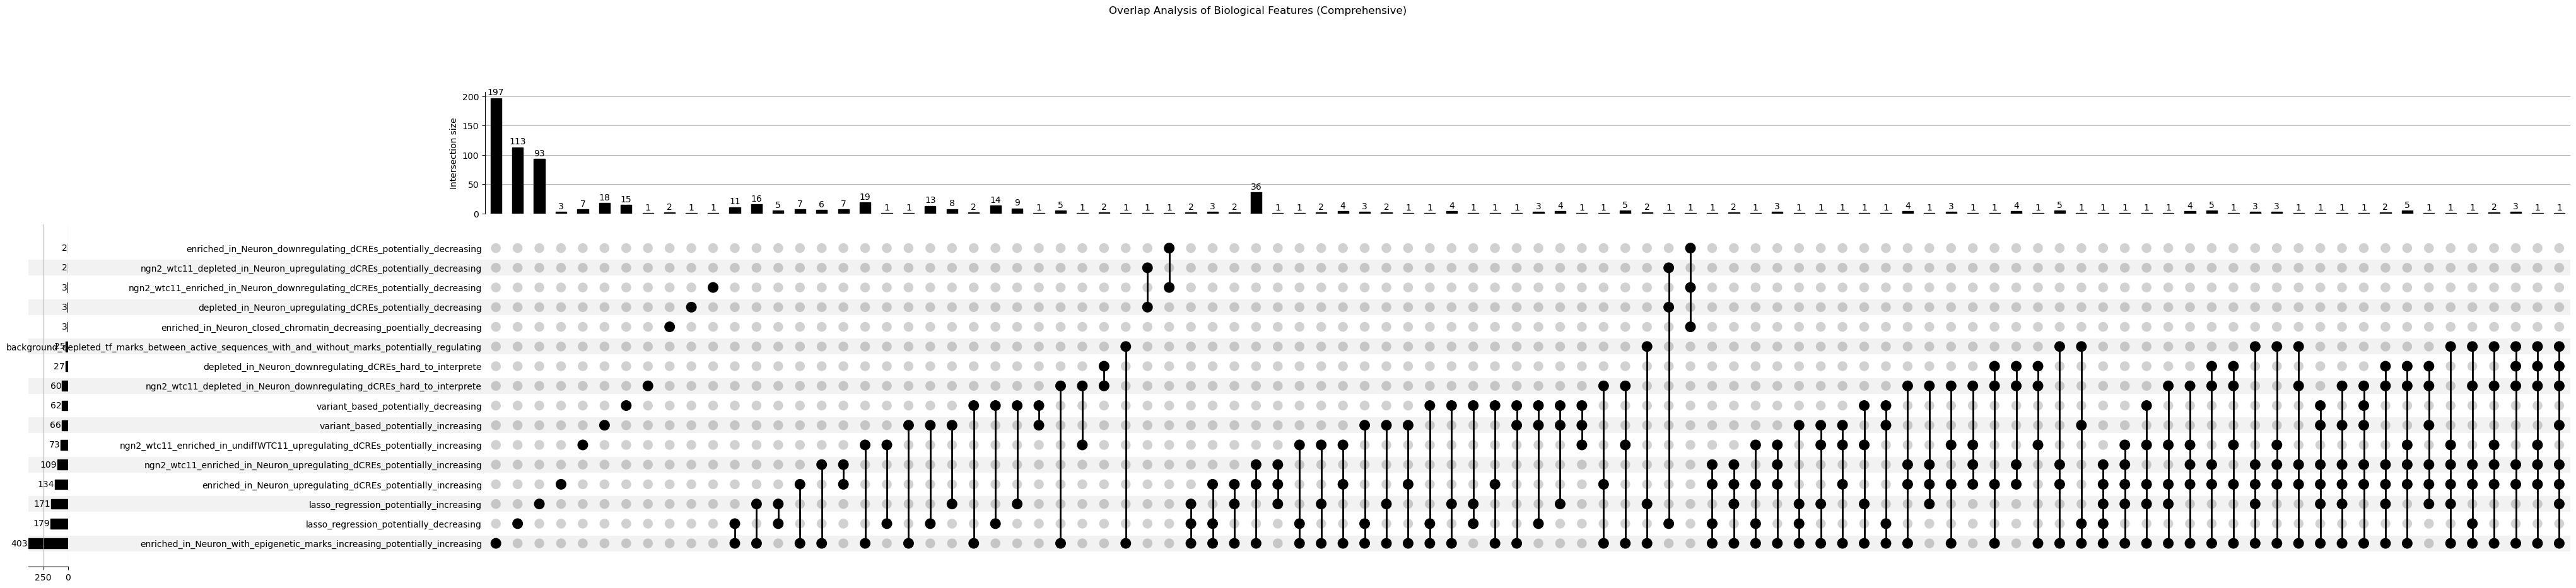

In [74]:
from upsetplot import plot, from_contents
import pandas as pd
import matplotlib.pyplot as plt
# Create a dictionary where keys are the exact set names for the plot
all_for_upset = {
    # Lasso Regression Based
    'lasso_regression_potentially_decreasing': make_list_unique(lasso_regression_potentially_decreasing, name='lasso_regression_potentially_decreasing'),
    'lasso_regression_potentially_increasing': make_list_unique(lasso_regression_potentially_increasing, name='lasso_regression_potentially_increasing'),

    # Variant Based
    'variant_based_potentially_decreasing': make_list_unique(variant_based_potentially_decreasing, name='variant_based_potentially_decreasing'),
    'variant_based_potentially_increasing': make_list_unique(variant_based_potentially_increasing, name='variant_based_potentially_increasing'),

    # Epigenetic marks
    'enriched_in_Neuron_with_epigenetic_marks_increasing_potentially_increasing': make_list_unique(enriched_in_Neuron_with_epigenetic_marks_increasing_potentially_increasing, "epigenetic_marks"),
    'enriched_in_Neuron_closed_chromatin_decreasing_poentially_decreasing': make_list_unique(enriched_in_Neuron_closed_chromatin_decreasing_poentially_decreasing, "epigenetic_marks"),
    'background_depleted_tf_marks_between_active_sequences_with_and_without_marks_potentially_regulating': make_list_unique(background_depleted_tf_marks_between_active_sequences_with_and_without_marks_potentially_regulating, "epigenetic_marks"),

    # NGN2 and undiffWTC11 high activity, low activity sequences vs background
    'ngn2_wtc11_depleted_in_Neuron_downregulating_dCREs_hard_to_interprete': make_list_unique(ngn2_wtc11_depleted_in_Neuron_downregulating_dCREs_hard_to_interprete, "ngn2_wtc11"),
    'ngn2_wtc11_depleted_in_Neuron_upregulating_dCREs_potentially_decreasing': make_list_unique(ngn2_wtc11_depleted_in_Neuron_upregulating_dCREs_potentially_decreasing, "ngn2_wtc11"),
    'ngn2_wtc11_enriched_in_Neuron_downregulating_dCREs_potentially_decreasing': make_list_unique(ngn2_wtc11_enriched_in_Neuron_downregulating_dCREs_potentially_decreasing, "ngn2_wtc11"),
    'ngn2_wtc11_enriched_in_Neuron_upregulating_dCREs_potentially_increasing': make_list_unique(ngn2_wtc11_enriched_in_Neuron_upregulating_dCREs_potentially_increasing, "ngn2_wtc11"),
    'ngn2_wtc11_enriched_in_undiffWTC11_upregulating_dCREs_potentially_increasing': make_list_unique(ngn2_wtc11_enriched_in_undiffWTC11_upregulating_dCREs_potentially_increasing, "ngn2_wtc11"),

    # NGN2 high_low activity sequences vs background
    'enriched_in_Neuron_upregulating_dCREs_potentially_increasing': make_list_unique(enriched_in_Neuron_upregulating_dCREs_potentially_increasing, name='enriched_in_Neuron_upregulating_dCREs_potentially_increasing'),
    'enriched_in_Neuron_downregulating_dCREs_potentially_decreasing': make_list_unique(enriched_in_Neuron_downregulating_dCREs_potentially_decreasing, name='enriched_in_Neuron_downregulating_dCREs_potentially_decreasing'),
    'depleted_in_Neuron_upregulating_dCREs_potentially_decreasing': make_list_unique(depleted_in_Neuron_upregulating_dCREs_potentially_decreasing, name='depleted_in_Neuron_upregulating_dCREs_potentially_decreasing'),
    'depleted_in_Neuron_downregulating_dCREs_hard_to_interprete': make_list_unique(depleted_in_Neuron_downregulating_dCREs_hard_to_interprete, name='depleted_in_Neuron_downregulating_dCREs_hard_to_interprete'),
}

# Convert the dictionary of lists into a pandas Series suitable for UpSetPlot
data_series = from_contents(all_for_upset)

# Generate the UpSet plot
plt.figure(figsize=(20, 14)) # Adjusted figure size for potentially more complex plot
plot(data_series, subset_size='count', show_counts=True, sort_by='degree',
     orientation='horizontal' # Use horizontal orientation for better readability with many set names
    )
plt.suptitle('Overlap Analysis of Biological Features (Comprehensive)', y=1.02)
# plt.savefig('upset_plot_biological_features_comprehensive.png', bbox_inches='tight', dpi=300)
plt.show()

### Question to be answered:
- Overview: How well do the sequence based, sequences set based and variant based TFBS identification methods agree:
    - Jaccard index of TFBS sets, Jaccard index of TFBS sets with positive influence and Jaccard index of TFBS sets with negative influence
- What is my ground truth? - Expected TFBS based on expression in excitatory neurons, or inhibitory neurons 
- Sanity check: Is the overlap of TFBS with positive influence in the activity of sequences enriched for TFBS actually expressed in the tested cell?
    - Overlap of the TFBS 

- Anhand dieser Daten würde ich die folgende Liste als reprimierend in diesem Zell-typ definieren:

- Anhand dieser Daten scheinen diese TFs die Transkription zu erhöhen

lasso_regression_potentially_increasing
variant_based_potentially_increasing


/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth

<Figure size 2000x1400 with 0 Axes>

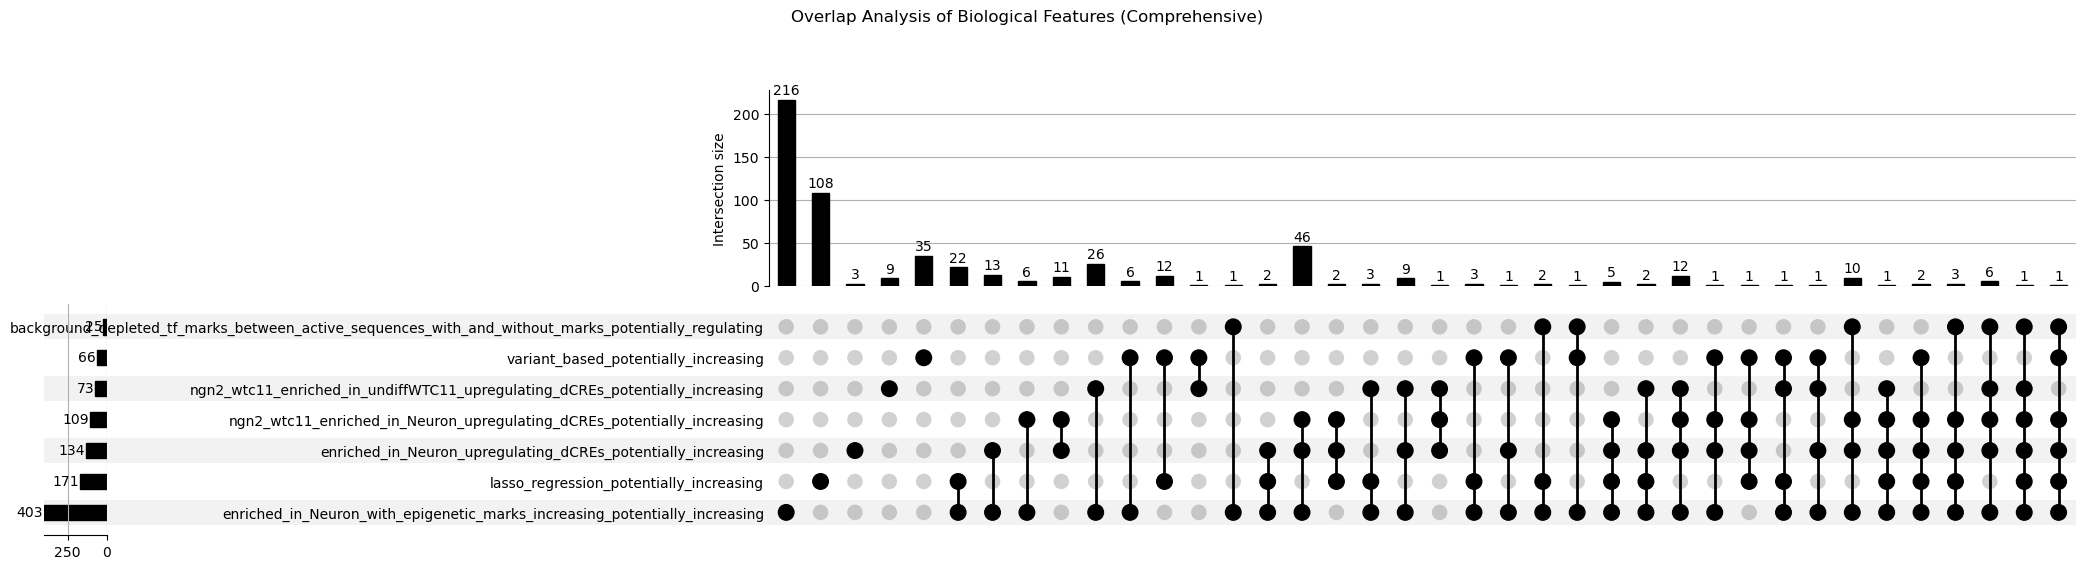

In [80]:
from upsetplot import plot, from_contents
import pandas as pd
import matplotlib.pyplot as plt
# Create a dictionary where keys are the exact set names for the plot
all_for_upset = {
    # Lasso Regression Based
    'lasso_regression_potentially_increasing': make_list_unique(lasso_regression_potentially_increasing, name='lasso_regression_potentially_increasing'),

    # Variant Based
    'variant_based_potentially_increasing': make_list_unique(variant_based_potentially_increasing, name='variant_based_potentially_increasing'),

    # Epigenetic marks
    'enriched_in_Neuron_with_epigenetic_marks_increasing_potentially_increasing': make_list_unique(enriched_in_Neuron_with_epigenetic_marks_increasing_potentially_increasing, "epigenetic_marks"),
    'background_depleted_tf_marks_between_active_sequences_with_and_without_marks_potentially_regulating': make_list_unique(background_depleted_tf_marks_between_active_sequences_with_and_without_marks_potentially_regulating, "epigenetic_marks"),

    # NGN2 and undiffWTC11 high activity, low activity sequences vs background
    'ngn2_wtc11_enriched_in_Neuron_upregulating_dCREs_potentially_increasing': make_list_unique(ngn2_wtc11_enriched_in_Neuron_upregulating_dCREs_potentially_increasing, "ngn2_wtc11"),
    'ngn2_wtc11_enriched_in_undiffWTC11_upregulating_dCREs_potentially_increasing': make_list_unique(ngn2_wtc11_enriched_in_undiffWTC11_upregulating_dCREs_potentially_increasing, "ngn2_wtc11"),

    # NGN2 high_low activity sequences vs background
    'enriched_in_Neuron_upregulating_dCREs_potentially_increasing': make_list_unique(enriched_in_Neuron_upregulating_dCREs_potentially_increasing, name='enriched_in_Neuron_upregulating_dCREs_potentially_increasing'),
}

# Convert the dictionary of lists into a pandas Series suitable for UpSetPlot
data_series = from_contents(all_for_upset)

# Generate the UpSet plot
plt.figure(figsize=(20, 14)) # Adjusted figure size for potentially more complex plot
plot(data_series, subset_size='count', show_counts=True, sort_by='degree',
     orientation='horizontal' # Use horizontal orientation for better readability with many set names
    )
plt.suptitle('Overlap Analysis of Biological Features (Comprehensive)', y=1.02)
# plt.savefig('upset_plot_biological_features_comprehensive.png', bbox_inches='tight', dpi=300)
plt.show()

In [1]:
import pandas as pd
expected_h13_tfbs_neuron_undiffWTC11_path = "/home/kisa/coding/80K_MPRA/remap_chipseq_pia/expected_TFBS_in_undiffWTC11_and_NGN2_neurons_cell_type_genexpression.tsv.gz"
expected_h13_tfbs_neuron_undiffWTC11 = pd.read_csv(expected_h13_tfbs_neuron_undiffWTC11_path, sep="\t")
expected_h13_tfbs_neuron_undiffWTC11

,Excitatory neurons,Inhibitory neurons,Undifferentiated cells,gene_symbol,motif_id,uniprot_id,uniprot_accession_num,cluster_motifs,is_TFBS
0,1,1,1,AHCTF1,AHCTF1.H13CORE.0.B.B,ELYS_HUMAN,Q8WYP5,"['AHCTF1.H13CORE.0.B.B', 'GLYR1.H13CORE.0.B.B']",1.0
1,1,1,1,AHR,AHR.H13CORE.0.P.B,AHR_HUMAN,P35869,"['AHR.H13CORE.0.P.B', 'AHRR.H13CORE.0.P.C']",1.0
2,0,0,1,ALX1,ALX1.H13CORE.0.SM.B,ALX1_HUMAN,Q15699,"['ALX1.H13CORE.0.SM.B', 'ALX4.H13CORE.0.S.B', ...",1.0
3,1,1,1,AR,ANDR.H13CORE.2.P.B,ANDR_HUMAN,P10275,['ANDR.H13CORE.2.P.B'],1.0
4,1,1,1,AR,ANDR.H13CORE.1.S.C,ANDR_HUMAN,P10275,"['ANDR.H13CORE.1.S.C', 'GCR.H13CORE.1.S.B', 'M...",1.0
...,...,...,...,...,...,...,...,...,...
609,1,1,1,ZSCAN29,ZSC29.H13CORE.1.M.C,ZSC29_HUMAN,Q8IWY8,['ZSC29.H13CORE.1.M.C'],1.0
610,1,1,1,ZSCAN31,ZSC31.H13CORE.0.P.C,ZSC31_HUMAN,Q96LW9,"['ZSC31.H13CORE.0.P.C', 'ZSC31.H13CORE.1.SM.B']",1.0
611,1,1,1,ZSCAN5A,ZSA5A.H13CORE.0.SM.B,ZSA5A_HUMAN,Q9BUG6,['ZSA5A.H13CORE.0.SM.B'],1.0
612,1,1,1,ZXDA,ZXDA.H13CORE.0.PSI.A,ZXDA_HUMAN,P98168,"['ZXDA.H13CORE.0.PSI.A', 'ZXDB.H13CORE.0.PI.A']",1.0


### What can you say about the closed chromatin sequences?
- We can plot the biosamples these sequences are considered active in
- we have no significant enrichment in the closed chromatin sequences

In [99]:
biosample_active_path = "/home/kisa/coding/80K_MPRA/cCREs_overlap/SCREEN_tissue/screen_summary_of_SCREEN_ids_without_marks_in_Neurons.csv.gz"
biosample_active = pd.read_csv(biosample_active_path, sep="\t", low_memory=False)

import ast
# Function to safely evaluate string representations of lists
def safe_eval(x):
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return x

biosample_active['Active_Biosamples_in_Target_Group'] = biosample_active['Active_Biosamples_in_Target_Group'].apply(safe_eval)


def get_length_of_active_biosamples(biosample_active):
    """Returns the length of the biosample_active dataframe."""
    return len(biosample_active)

biosample_active['n_biosamples'] = biosample_active['Active_Biosamples_in_Target_Group'].apply(get_length_of_active_biosamples)

<Axes: >

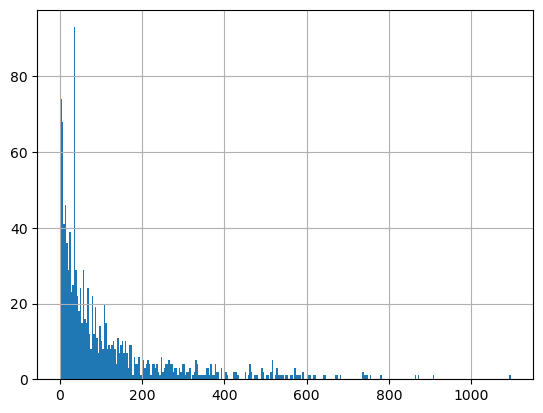

In [100]:
biosample_active['n_biosamples'].hist(bins=300)

In [ ]:
from collections import Counter
import re

def get_word_frequency_and_most_frequent(string_list):
    """
    Calculates the frequency of each word in a list of strings
    and identifies the most frequent word.

    Args:
        string_list (list of str): A list of strings.

    Returns:
        tuple: A tuple containing:
            - word_counts (collections.Counter): A Counter object with word frequencies.
            - most_frequent_word (str or None): The most frequent word, or None if the list is empty.
            - max_frequency (int): The frequency of the most frequent word.
    """
    all_words = []
    for s in string_list:
        # Use regex to find all alphabetic words, convert to lowercase
        # This handles punctuation and ensures case-insensitivity
        words = re.findall(r'\b[a-zA-Z]+\b', s.lower())
        all_words.extend(words)

    if not all_words:
        return Counter(), None, 0

    # Calculate word frequencies
    word_counts = Counter(all_words)

    # Find the most frequent word
    most_frequent_word_info = word_counts.most_common(1)

    if most_frequent_word_info:
        most_frequent_word, max_frequency = most_frequent_word_info[0]
    else:
        most_frequent_word, max_frequency = None, 0 # Should not happen if all_words is not empty

    return word_counts, most_frequent_word, max_frequency


def get_most_frequent_words_active_biosample_column(biosample_active):
    """
    """
    word_frequencies, most_common, highest_freq = get_word_frequency_and_most_frequent(biosample_active)
    return most_common

In [103]:
type(biosample_active['Active_Biosamples_in_Target_Group'][0][0])

str

In [105]:
biosample_active['most_frequent_word'] = biosample_active['Active_Biosamples_in_Target_Group'].apply(get_most_frequent_words_active_biosample_column)

In [106]:
biosample_active['most_frequent_word']

0            male
1           adult
2            days
3           years
4       intestine
          ...    
1201        years
1202         cell
1203           in
1204        years
1205         days
Name: most_frequent_word, Length: 1206, dtype: object

In [107]:
biosample_active['Active_Biosamples_in_Target_Group']

0       [Ammon's horn, male adult (84 years), brain, e...
1       [22Rv1, treated with 10 nM 17β-hydroxy-5α-andr...
2       [cardiac muscle cell (in vitro differentiated ...
3       [aorta, male adult (34 years), ascending aorta...
4       [hepatocyte (in vitro differentiated cells), l...
                              ...                        
1201    [A549, treated with 0.02 percent ethanol for 1...
1202    [ACHN, activated CD4-positive, alpha-beta T ce...
1203    [bipolar neuron (in vitro differentiated cells...
1204    [22Rv1, 22Rv1, treated with 10 nM 17β-hydroxy-...
1205    [A673, bipolar neuron (in vitro differentiated...
Name: Active_Biosamples_in_Target_Group, Length: 1206, dtype: object

### Measure the quality of a dataset based on the agreement of the TFBS set with the expressed TFs

In [2]:
expressed_in_neurons_hocomoco13 = expected_h13_tfbs_neuron_undiffWTC11.loc[expected_h13_tfbs_neuron_undiffWTC11["Excitatory neurons"] == 1].copy()

In [3]:
expressed_in_neurons_hocomoco13_dedup = expressed_in_neurons_hocomoco13.loc[~expressed_in_neurons_hocomoco13['gene_symbol'].duplicated()]

In [4]:
expressed_in_neurons_hocomoco13_dedup

,Excitatory neurons,Inhibitory neurons,Undifferentiated cells,gene_symbol,motif_id,uniprot_id,uniprot_accession_num,cluster_motifs,is_TFBS
0,1,1,1,AHCTF1,AHCTF1.H13CORE.0.B.B,ELYS_HUMAN,Q8WYP5,"['AHCTF1.H13CORE.0.B.B', 'GLYR1.H13CORE.0.B.B']",1.0
1,1,1,1,AHR,AHR.H13CORE.0.P.B,AHR_HUMAN,P35869,"['AHR.H13CORE.0.P.B', 'AHRR.H13CORE.0.P.C']",1.0
3,1,1,1,AR,ANDR.H13CORE.2.P.B,ANDR_HUMAN,P10275,['ANDR.H13CORE.2.P.B'],1.0
5,1,1,1,ARNT,ARNT.H13CORE.0.P.B,ARNT_HUMAN,P27540,"['ARNT.H13CORE.0.P.B', 'ARNT.H13CORE.1.P.B', '...",1.0
6,1,1,1,ARNT2,ARNT2.H13CORE.0.P.B,ARNT2_HUMAN,Q9HBZ2,['ARNT2.H13CORE.0.P.B'],1.0
...,...,...,...,...,...,...,...,...,...
608,1,1,1,ZSCAN29,ZSC29.H13CORE.0.P.B,ZSC29_HUMAN,Q8IWY8,['ZSC29.H13CORE.0.P.B'],1.0
610,1,1,1,ZSCAN31,ZSC31.H13CORE.0.P.C,ZSC31_HUMAN,Q96LW9,"['ZSC31.H13CORE.0.P.C', 'ZSC31.H13CORE.1.SM.B']",1.0
611,1,1,1,ZSCAN5A,ZSA5A.H13CORE.0.SM.B,ZSA5A_HUMAN,Q9BUG6,['ZSA5A.H13CORE.0.SM.B'],1.0
612,1,1,1,ZXDA,ZXDA.H13CORE.0.PSI.A,ZXDA_HUMAN,P98168,"['ZXDA.H13CORE.0.PSI.A', 'ZXDB.H13CORE.0.PI.A']",1.0


In [5]:
expressed_in_neurons_hocomoco13_dedup

,Excitatory neurons,Inhibitory neurons,Undifferentiated cells,gene_symbol,motif_id,uniprot_id,uniprot_accession_num,cluster_motifs,is_TFBS
0,1,1,1,AHCTF1,AHCTF1.H13CORE.0.B.B,ELYS_HUMAN,Q8WYP5,"['AHCTF1.H13CORE.0.B.B', 'GLYR1.H13CORE.0.B.B']",1.0
1,1,1,1,AHR,AHR.H13CORE.0.P.B,AHR_HUMAN,P35869,"['AHR.H13CORE.0.P.B', 'AHRR.H13CORE.0.P.C']",1.0
3,1,1,1,AR,ANDR.H13CORE.2.P.B,ANDR_HUMAN,P10275,['ANDR.H13CORE.2.P.B'],1.0
5,1,1,1,ARNT,ARNT.H13CORE.0.P.B,ARNT_HUMAN,P27540,"['ARNT.H13CORE.0.P.B', 'ARNT.H13CORE.1.P.B', '...",1.0
6,1,1,1,ARNT2,ARNT2.H13CORE.0.P.B,ARNT2_HUMAN,Q9HBZ2,['ARNT2.H13CORE.0.P.B'],1.0
...,...,...,...,...,...,...,...,...,...
608,1,1,1,ZSCAN29,ZSC29.H13CORE.0.P.B,ZSC29_HUMAN,Q8IWY8,['ZSC29.H13CORE.0.P.B'],1.0
610,1,1,1,ZSCAN31,ZSC31.H13CORE.0.P.C,ZSC31_HUMAN,Q96LW9,"['ZSC31.H13CORE.0.P.C', 'ZSC31.H13CORE.1.SM.B']",1.0
611,1,1,1,ZSCAN5A,ZSA5A.H13CORE.0.SM.B,ZSA5A_HUMAN,Q9BUG6,['ZSA5A.H13CORE.0.SM.B'],1.0
612,1,1,1,ZXDA,ZXDA.H13CORE.0.PSI.A,ZXDA_HUMAN,P98168,"['ZXDA.H13CORE.0.PSI.A', 'ZXDB.H13CORE.0.PI.A']",1.0


##### Lasso regression

In [7]:
# Functions to get the information about considered expressed transcription factors
def from_masterlist_info_2_gene_symbol(masterlist_info):
    """Expects to get a dict as input and tried to read the human gene_symbol"""
    try:
        gene_symbol = masterlist_info['species']['HUMAN']['gene_symbol']
        uniprot_id =  masterlist_info['species']['HUMAN']['uniprot_id']
        uniprot_accession_num =  masterlist_info['species']['HUMAN']['uniprot_ac']
    except:
        print("Problem during finding gene symbol of the following masterlist info: ", masterlist_info)
        gene_symbol = pd.NA
    return pd.Series({'gene_symbol': gene_symbol, 'uniprot_id': uniprot_id, 'uniprot_accession_num': uniprot_accession_num})

In [8]:
hocomoco_annotation_info_path = "/home/kisa/coding/ISMB-2025_IGVF-MPRA-Tutorial/06_variant_effects_and_motifs/resources/hocomoco_v13/H13CORE-CLUSTERED_annotation.jsonl"
hocomoco_annotation_info_all = pd.read_json(path_or_buf=hocomoco_annotation_info_path, lines=True)
hocomoco_annotation_info_all

# rename name
hocomoco_annotation_info = hocomoco_annotation_info_all.rename(columns={"name": "motif_id"}).copy()

hocomoco_annotation_info[['gene_symbol', 'uniprot_id', 'uniprot_accession_num']] = hocomoco_annotation_info["masterlist_info"].apply(from_masterlist_info_2_gene_symbol)
hocomoco_annotation_info
# only name and tf name
hocomoco_annotation_info = hocomoco_annotation_info[['motif_id', 'gene_symbol', 'uniprot_id', 'uniprot_accession_num', 'cluster_motifs']].copy()
# add gene info
# variant_metadata_fimo_combined_df_all_AFs_variant_overlapping = variant_metadata_fimo_combined_df_all_AFs_variant_overlapping.merge(hocomoco_annotation_info[['motif_id', 'gene_symbol']], on="motif_id", how="inner").copy()


# binary_gene_activity_matrix_path = "/home/kisa/coding/ISMB-2025_IGVF-MPRA-Tutorial/06_variant_effects_and_motifs/resources/gene_matrix_specificity_by_percentage.tsv.gz"
# binary_gene_activity_matrix_df = pd.read_csv(binary_gene_activity_matrix_path, sep="\t", low_memory=False)
# binary_gene_activity_matrix_df_specificity = binary_gene_activity_matrix_df[["gene_symbol", "Excitatory neurons", "Inhibitory neurons", "SpecificityLabel"]]
# binary_gene_activity_matrix_df_specificity

# variant_metadata_fimo_combined_df_all_AFs_variant_overlapping = variant_metadata_fimo_combined_df_all_AFs_variant_overlapping.merge(binary_gene_activity_matrix_df_specificity, on="gene_symbol", how="left")

In [9]:
hocomoco_annotation_info

,motif_id,gene_symbol,uniprot_id,uniprot_accession_num,cluster_motifs
0,ZBED5.H13CORE.0.PSGIB.A,ZBED5,ZBED5_HUMAN,Q49AG3,[ZBED5.H13CORE.0.PSGIB.A]
1,ZFAT.H13CORE.0.PSGI.A,ZFAT,ZFAT_HUMAN,Q9P243,[ZFAT.H13CORE.0.PSGI.A]
2,ZSCAN2.H13CORE.0.PG.A,ZSCAN2,ZSCA2_HUMAN,Q7Z7L9,[ZSCAN2.H13CORE.0.PG.A]
3,ZFTA.H13CORE.0.PSGIB.A,ZFTA,ZFTA_HUMAN,C9JLR9,[ZFTA.H13CORE.0.PSGIB.A]
4,ZNF226.H13CORE.0.PSGI.A,ZNF226,ZN226_HUMAN,Q9NYT6,"[ZNF226.H13CORE.0.PSGI.A, ZNF234.H13CORE.0.PSG.A]"
...,...,...,...,...,...
648,ZSC23.H13CORE.0.M.C,ZSCAN23,ZSC23_HUMAN,Q3MJ62,[ZSC23.H13CORE.0.M.C]
649,ZSC29.H13CORE.0.P.B,ZSCAN29,ZSC29_HUMAN,Q8IWY8,[ZSC29.H13CORE.0.P.B]
650,ZSC29.H13CORE.1.M.C,ZSCAN29,ZSC29_HUMAN,Q8IWY8,[ZSC29.H13CORE.1.M.C]
651,ZSC31.H13CORE.0.P.C,ZSCAN31,ZSC31_HUMAN,Q96LW9,"[ZSC31.H13CORE.0.P.C, ZSC31.H13CORE.1.SM.B]"


In [11]:
# how many of the initially used:
# zcat /home/kisa/coding/80K_MPRA/element_variant_analysis_output/tfbs_analysis/lasso_regression_sequence_motif_table.tsv.gz | cut -f 1 | sort | uniq > /home/kisa/coding/80K_MPRA/element_variant_analysis_output/tfbs_analysis/lasso_regression_only_motifs_used.tsv
lasso_regression_input_table_path = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/tfbs_analysis/lasso_regression_only_motifs_used.tsv"
lass_all_input_motifs = pd.read_csv(lasso_regression_input_table_path, sep="\t", low_memory=False)
lass_all_input_motifs_list = lass_all_input_motifs['motif_id'].to_list()
lass_all_input_motifs_with_info = lass_all_input_motifs.merge(hocomoco_annotation_info[['motif_id', 'gene_symbol']], on="motif_id", how="left").copy()
lass_all_input_motifs_with_info

,motif_id,gene_symbol
0,ZN441.H13CORE.1.P.C,ZNF441
1,ZNF646.H13CORE.0.PSG.A,ZNF646
2,ZNF48.H13CORE.0.PSG.A,ZNF48
3,ZNF233.H13CORE.0.PG.A,ZNF233
4,ZN560.H13CORE.0.P.C,ZNF560
...,...,...
647,TERF1.H13CORE.0.PSGB.A,TERF1
648,NKX61.H13CORE.1.P.B,NKX6-1
649,LMX1B.H13CORE.0.P.C,LMX1B
650,CPEB1.H13CORE.0.S.B,CPEB1


In [19]:
lass_all_input_motifs_with_info

,motif_id,gene_symbol
0,ZN441.H13CORE.1.P.C,ZNF441
1,ZNF646.H13CORE.0.PSG.A,ZNF646
2,ZNF48.H13CORE.0.PSG.A,ZNF48
3,ZNF233.H13CORE.0.PG.A,ZNF233
4,ZN560.H13CORE.0.P.C,ZNF560
...,...,...
647,TERF1.H13CORE.0.PSGB.A,TERF1
648,NKX61.H13CORE.1.P.B,NKX6-1
649,LMX1B.H13CORE.0.P.C,LMX1B
650,CPEB1.H13CORE.0.S.B,CPEB1


In [25]:
lass_all_input_motifs_with_info[["gene_symbol"]].merge(expressed_in_neurons_hocomoco13_dedup, on="gene_symbol", how="inner").drop_duplicates(subset="gene_symbol").shape[0] / lass_all_input_motifs_with_info.shape[0]

0.7944785276073619

In [ ]:
# lasso:
print("Lasso regression based: ")
lasso_regression_increasing_expressed_in_neurons_overlap = expressed_in_neurons_hocomoco13_dedup.loc[expressed_in_neurons_hocomoco13_dedup['gene_symbol'].isin(lass_all_input_motifs_list)].shape[0]
lasso_regression_increasing_expressed_in_neurons_overlap / len(lasso_regression_potentially_increasing)
print("Potentially increasing TFBS motifs: ", lasso_regression_increasing_expressed_in_neurons_overlap / len(lasso_regression_potentially_increasing))

In [74]:
lasso_regression_potentially_increasing = list(set(lasso_regression_potentially_increasing))
lasso_regression_potentially_decreasing = list(set(lasso_regression_potentially_decreasing))

In [78]:
print("Number of lasso regression potentially increasing TFBS: ", len(lasso_regression_potentially_increasing))
print("Number of lasso regression potentially decreasing TFBS: ", len(lasso_regression_potentially_decreasing))

Number of lasso regression potentially increasing TFBS:  171
Number of lasso regression potentially decreasing TFBS:  179


In [81]:
combined_lasso = set(lasso_regression_potentially_decreasing).union(set(lasso_regression_potentially_decreasing))

In [82]:
# lasso:
print("Lasso regression based: ")
lasso_regression_increasing_expressed_in_neurons_overlap = expressed_in_neurons_hocomoco13_dedup.loc[expressed_in_neurons_hocomoco13_dedup['gene_symbol'].isin(lasso_regression_potentially_increasing)].shape[0]
lasso_regression_increasing_expressed_in_neurons_overlap / len(lasso_regression_potentially_increasing)
print("Potentially increasing TFBS motifs: ", lasso_regression_increasing_expressed_in_neurons_overlap / len(lasso_regression_potentially_increasing))

lasso_regression_potentially_decreasing_expressed_in_neurons_overlap = expressed_in_neurons_hocomoco13_dedup.loc[expressed_in_neurons_hocomoco13_dedup['gene_symbol'].isin(lasso_regression_potentially_decreasing)].shape[0]
lasso_regression_potentially_decreasing_expressed_in_neurons_overlap / len(lasso_regression_potentially_decreasing)
print("Potentially decreasing TFBS motifs: ", lasso_regression_potentially_decreasing_expressed_in_neurons_overlap / len(lasso_regression_potentially_decreasing))
combined_lasso_expressed_in_neurons_overlap = expressed_in_neurons_hocomoco13_dedup.loc[expressed_in_neurons_hocomoco13_dedup['gene_symbol'].isin(combined_lasso)].shape[0]
combined_lasso_expressed_in_neurons_overlap / len(combined_lasso)
print("Potentially decreasing TFBS motifs: ", combined_lasso_expressed_in_neurons_overlap / len(combined_lasso))

Lasso regression based: 
Potentially increasing TFBS motifs:  0.8187134502923976
Potentially decreasing TFBS motifs:  0.9217877094972067
Potentially decreasing TFBS motifs:  0.9217877094972067


##### Variant based TFBS

In [55]:
print("Variant based overlap with expressed in neurons HOCOMOCO13:")
variant_based_potentially_decreasing_expressed_in_neurons_overlap = expressed_in_neurons_hocomoco13_dedup.loc[expressed_in_neurons_hocomoco13_dedup['gene_symbol'].isin(variant_based_potentially_decreasing)].shape[0]
variant_based_potentially_decreasing_expressed_in_neurons_overlap / len(variant_based_potentially_decreasing)
print("Potentially decreasing TFBS motifs: ", variant_based_potentially_decreasing_expressed_in_neurons_overlap / len(variant_based_potentially_decreasing))
# variant_based_potentially_decreasing
# variant_based_potentially_increasing

variant_based_potentially_increasing_expressed_in_neurons_overlap = expressed_in_neurons_hocomoco13_dedup.loc[expressed_in_neurons_hocomoco13_dedup['gene_symbol'].isin(variant_based_potentially_increasing)].shape[0]
variant_based_potentially_increasing_expressed_in_neurons_overlap / len(variant_based_potentially_increasing)
print("Potentially increasing TFBS motifs: ", variant_based_potentially_increasing_expressed_in_neurons_overlap / len(variant_based_potentially_increasing))
# variant_based_potentially_increasing = expressed_in_neurons_hocomoco13_dedup.loc[expressed_in_neurons_hocomoco13_dedup['gene_symbol'].isin(lasso_regression_potentially_increasing)].shape[0]
# variant_based_potentially_increasing / len(lasso_regression_potentially_increasing)

Variant based overlap with expressed in neurons HOCOMOCO13:
Potentially decreasing TFBS motifs:  0.8260869565217391
Potentially increasing TFBS motifs:  0.717948717948718


In [ ]:
enriched_in_Neuron_upregulating_dCREs_potentially_increasing
enriched_in_Neuron_downregulating_dCREs_potentially_decreasing
depleted_in_Neuron_upregulating_dCREs_potentially_decreasing
depleted_in_Neuron_downregulating_dCREs_hard_to_interprete

In [57]:
print("Neuron increasing vs decreasing sequences compared using RegioneReloaded: ")

enriched_in_Neuron_upregulating_dCREs_potentially_increasing_expressed_in_neurons_overlap = expressed_in_neurons_hocomoco13_dedup.loc[expressed_in_neurons_hocomoco13_dedup['gene_symbol'].isin(enriched_in_Neuron_upregulating_dCREs_potentially_increasing)].shape[0]
print("Enriched in Neuron upregulating dCREs potentially increasing overlap with expressed TFBS: ", enriched_in_Neuron_upregulating_dCREs_potentially_increasing_expressed_in_neurons_overlap / len(enriched_in_Neuron_upregulating_dCREs_potentially_increasing))
enriched_in_Neuron_downregulating_dCREs_potentially_decreasing_expressed_in_neurons_overlap = expressed_in_neurons_hocomoco13_dedup.loc[expressed_in_neurons_hocomoco13_dedup['gene_symbol'].isin(enriched_in_Neuron_downregulating_dCREs_potentially_decreasing)].shape[0]
print("Enriched in Neuron downregulating dCREs potentially decreasing overlap with expressed TFBS: ", enriched_in_Neuron_downregulating_dCREs_potentially_decreasing_expressed_in_neurons_overlap / len(enriched_in_Neuron_downregulating_dCREs_potentially_decreasing))
depleted_in_Neuron_upregulating_dCREs_potentially_decreasing_expressed_in_neurons_overlap = expressed_in_neurons_hocomoco13_dedup.loc[expressed_in_neurons_hocomoco13_dedup['gene_symbol'].isin(depleted_in_Neuron_upregulating_dCREs_potentially_decreasing)].shape[0]
print("Depleted in Neuron upregulating dCREs potentially decreasing overlap with expressed TFBS: ", depleted_in_Neuron_upregulating_dCREs_potentially_decreasing_expressed_in_neurons_overlap / len(depleted_in_Neuron_upregulating_dCREs_potentially_decreasing))
depleted_in_Neuron_downregulating_dCREs_hard_to_interprete_expressed_in_neurons_overlap = expressed_in_neurons_hocomoco13_dedup.loc[expressed_in_neurons_hocomoco13_dedup['gene_symbol'].isin(depleted_in_Neuron_downregulating_dCREs_hard_to_interprete)].shape[0]
print("Depleted in Neuron downregulating dCREs hard to interpret overlap with expressed TFBS: ", depleted_in_Neuron_downregulating_dCREs_hard_to_interprete_expressed_in_neurons_overlap / len(depleted_in_Neuron_downregulating_dCREs_hard_to_interprete))

Neuron increasing vs decreasing sequences compared using RegioneReloaded: 
Enriched in Neuron upregulating dCREs potentially increasing overlap with expressed TFBS:  0.26119402985074625
Enriched in Neuron downregulating dCREs potentially decreasing overlap with expressed TFBS:  0.0
Depleted in Neuron upregulating dCREs potentially decreasing overlap with expressed TFBS:  0.3333333333333333
Depleted in Neuron downregulating dCREs hard to interpret overlap with expressed TFBS:  0.18518518518518517


In [61]:
enriched_in_Neuron_downregulating_dCREs_potentially_decreasing

['DNMT3B', 'ZZZ3']

In [ ]:
# Epigenetic marks:
enriched_in_Neuron_with_epigenetic_marks_increasing_potentially_increasing
enriched_in_Neuron_closed_chromatin_decreasing_poentially_decreasing
background_depleted_tf_marks_between_active_sequences_with_and_without_marks_potentially_regulating

In [60]:
enriched_in_Neuron_closed_chromatin_decreasing_poentially_decreasing

['ETV6', 'GLYR1', 'ZZZ3']

In [62]:
enriched_in_Neuron_with_epigenetic_marks_increasing_potentially_increasing_expressed_in_neurons_overlap = expressed_in_neurons_hocomoco13_dedup.loc[expressed_in_neurons_hocomoco13_dedup['gene_symbol'].isin(enriched_in_Neuron_with_epigenetic_marks_increasing_potentially_increasing)].shape[0]
print("Enriched in Neuron with epigenetic marks potentially increasing overlap with expressed TFBS: ", enriched_in_Neuron_with_epigenetic_marks_increasing_potentially_increasing_expressed_in_neurons_overlap / len(enriched_in_Neuron_with_epigenetic_marks_increasing_potentially_increasing))

enriched_in_Neuron_closed_chromatin_decreasing_poentially_decreasing_expressed_in_neurons_overlap = expressed_in_neurons_hocomoco13_dedup.loc[expressed_in_neurons_hocomoco13_dedup['gene_symbol'].isin(enriched_in_Neuron_closed_chromatin_decreasing_poentially_decreasing)].shape[0]
print("Enriched in Neuron closed chromatin decreasing potentially decreasing overlap with expressed TFBS: ", enriched_in_Neuron_closed_chromatin_decreasing_poentially_decreasing_expressed_in_neurons_overlap / len(enriched_in_Neuron_closed_chromatin_decreasing_poentially_decreasing))

background_depleted_tf_marks_between_active_sequences_with_and_without_marks_potentially_regulating_expressed_in_neurons_overlap = expressed_in_neurons_hocomoco13_dedup.loc[expressed_in_neurons_hocomoco13_dedup['gene_symbol'].isin(background_depleted_tf_marks_between_active_sequences_with_and_without_marks_potentially_regulating)].shape[0]
print("Background depleted TF marks between active sequences with and without marks potentially regulating overlap with expressed TFBS: ", background_depleted_tf_marks_between_active_sequences_with_and_without_marks_potentially_regulating_expressed_in_neurons_overlap / len(background_depleted_tf_marks_between_active_sequences_with_and_without_marks_potentially_regulating))

Enriched in Neuron with epigenetic marks potentially increasing overlap with expressed TFBS:  0.2729528535980149
Enriched in Neuron closed chromatin decreasing potentially decreasing overlap with expressed TFBS:  0.0
Background depleted TF marks between active sequences with and without marks potentially regulating overlap with expressed TFBS:  0.32


In [ ]:
# NGN2 and undiffWTC11 high activity, low activity sequences vs background
ngn2_wtc11_depleted_in_Neuron_downregulating_dCREs_hard_to_interprete
ngn2_wtc11_depleted_in_Neuron_upregulating_dCREs_potentially_decreasing # 2
ngn2_wtc11_enriched_in_Neuron_downregulating_dCREs_potentially_decreasing # 3
ngn2_wtc11_enriched_in_Neuron_upregulating_dCREs_potentially_increasing
ngn2_wtc11_enriched_in_undiffWTC11_upregulating_dCREs_potentially_increasing

In [69]:
ngn2_wtc11_depleted_in_Neuron_downregulating_dCREs_hard_to_interprete_expressed_in_neurons_overlap = expressed_in_neurons_hocomoco13_dedup.loc[expressed_in_neurons_hocomoco13_dedup['gene_symbol'].isin(ngn2_wtc11_depleted_in_Neuron_downregulating_dCREs_hard_to_interprete)].shape[0]
print("NGN2 WTC11 depleted in Neuron downregulating dCREs hard to interpret overlap with expressed TFBS: ", ngn2_wtc11_depleted_in_Neuron_downregulating_dCREs_hard_to_interprete_expressed_in_neurons_overlap / len(ngn2_wtc11_depleted_in_Neuron_downregulating_dCREs_hard_to_interprete))
ngn2_wtc11_depleted_in_Neuron_upregulating_dCREs_potentially_decreasing_expressed_in_neurons_overlap = expressed_in_neurons_hocomoco13_dedup.loc[expressed_in_neurons_hocomoco13_dedup['gene_symbol'].isin(ngn2_wtc11_depleted_in_Neuron_upregulating_dCREs_potentially_decreasing)].shape[0]
print("NGN2 WTC11 depleted in Neuron upregulating dCREs potentially decreasing overlap with expressed TFBS: ", ngn2_wtc11_depleted_in_Neuron_upregulating_dCREs_potentially_decreasing_expressed_in_neurons_overlap / len(ngn2_wtc11_depleted_in_Neuron_upregulating_dCREs_potentially_decreasing))
ngn2_wtc11_enriched_in_Neuron_downregulating_dCREs_potentially_decreasing_expressed_in_neurons_overlap = expressed_in_neurons_hocomoco13_dedup.loc[expressed_in_neurons_hocomoco13_dedup['gene_symbol'].isin(ngn2_wtc11_enriched_in_Neuron_downregulating_dCREs_potentially_decreasing)].shape[0]
print("NGN2 WTC11 enriched in Neuron downregulating dCREs potentially decreasing overlap with expressed TFBS: ", ngn2_wtc11_enriched_in_Neuron_downregulating_dCREs_potentially_decreasing_expressed_in_neurons_overlap / len(ngn2_wtc11_enriched_in_Neuron_downregulating_dCREs_potentially_decreasing))
ngn2_wtc11_enriched_in_Neuron_upregulating_dCREs_potentially_increasing_expressed_in_neurons_overlap = expressed_in_neurons_hocomoco13_dedup.loc[expressed_in_neurons_hocomoco13_dedup['gene_symbol'].isin(ngn2_wtc11_enriched_in_Neuron_upregulating_dCREs_potentially_increasing)].shape[0]
print("NGN2 WTC11 enriched in Neuron upregulating dCREs potentially increasing overlap with expressed TFBS: ", ngn2_wtc11_enriched_in_Neuron_upregulating_dCREs_potentially_increasing_expressed_in_neurons_overlap / len(ngn2_wtc11_enriched_in_Neuron_upregulating_dCREs_potentially_increasing))
ngn2_wtc11_enriched_in_undiffWTC11_upregulating_dCREs_potentially_increasing_expressed_in_neurons_overlap = expressed_in_neurons_hocomoco13_dedup.loc[expressed_in_neurons_hocomoco13_dedup['gene_symbol'].isin(ngn2_wtc11_enriched_in_undiffWTC11_upregulating_dCREs_potentially_increasing)].shape[0]
print("NGN2 WTC11 enriched in undiffWTC11 upregulating dCREs potentially increasing overlap with expressed TFBS: ", ngn2_wtc11_enriched_in_undiffWTC11_upregulating_dCREs_potentially_increasing_expressed_in_neurons_overlap / len(ngn2_wtc11_enriched_in_undiffWTC11_upregulating_dCREs_potentially_increasing))

NGN2 WTC11 depleted in Neuron downregulating dCREs hard to interpret overlap with expressed TFBS:  0.18333333333333332
NGN2 WTC11 depleted in Neuron upregulating dCREs potentially decreasing overlap with expressed TFBS:  0.5
NGN2 WTC11 enriched in Neuron downregulating dCREs potentially decreasing overlap with expressed TFBS:  0.0
NGN2 WTC11 enriched in Neuron upregulating dCREs potentially increasing overlap with expressed TFBS:  0.23853211009174313
NGN2 WTC11 enriched in undiffWTC11 upregulating dCREs potentially increasing overlap with expressed TFBS:  0.136986301369863


### 28 enriched ChIP TF marks in the background set (how useful is this?) (25 of those are depleted in the background set meaning they can be actual activity driving motifs)